# Part 1: Acne Detection on ACNE04

This notebook trains and compares **three object detectors** on the ACNE04 dataset:

| Model | Family | Anchors |
|---|---|---|
| **YOLOv8** | One-stage CNN | Anchor-free |
| **Faster R-CNN + ResNet50-FPN** | Two-stage CNN | Anchor-based |
| **RT-DETR** (DINO family) | One-stage Transformer | Anchor-free queries |

Run end-to-end on Colab (T4 GPU) in ~3 hours.


## 0. Setup

Link: https://github.com/nprakash1/acne_yang_project/tree/main/part1_detection

In [1]:
# Auto-detect how the project got into this Colab runtime.
# Supports three workflows -- you don't have to edit anything:
#   (1) git clone   - set GITHUB_URL below to a public repo URL
#   (2) zip upload  - drag acne_yang_project.zip into Colab's file pane
#   (3) Drive copy  - put the unzipped folder anywhere in your Drive
import os, glob, subprocess

GITHUB_URL = 'https://github.com/nprakash1/acne_yang_project.git'
PROJECT_DIR = 'acne_yang_project'

def _is_project_root(p):
    return os.path.isdir(os.path.join(p, 'part1_detection')) and \
           os.path.isfile(os.path.join(p, 'requirements.txt'))

# Already at project root?
if _is_project_root('.'):
    print('[setup] already at project root')
elif os.path.isdir(PROJECT_DIR) and _is_project_root(PROJECT_DIR):
    %cd $PROJECT_DIR
    print(f'[setup] cd into ./{PROJECT_DIR}')
else:
    zips = glob.glob('/content/*.zip') + glob.glob('./*.zip')
    drive_hits = glob.glob('/content/drive/MyDrive/**/part1_detection', recursive=True)
    if zips:
        z = zips[0]
        print(f'[setup] unzipping {z}')
        subprocess.check_call(['unzip', '-q', '-o', z, '-d', '/content/_extracted'])
        roots = [r for r, _, _ in os.walk('/content/_extracted') if _is_project_root(r)]
        assert roots, 'zip did not contain a project root (part1_detection/ + requirements.txt)'
        %cd $roots[0]
    elif drive_hits:
        root = os.path.dirname(drive_hits[0])
        print(f'[setup] using project from Drive: {root}')
        %cd $root
    elif GITHUB_URL:
        print(f'[setup] cloning {GITHUB_URL}')
        subprocess.check_call(['git', 'clone', GITHUB_URL])
        %cd $PROJECT_DIR
    else:
        raise RuntimeError(
            'No project source found. Either:\n'
            ' - set GITHUB_URL above to your repo, or\n'
            ' - drag acne_yang_project.zip into the Colab file pane and re-run, or\n'
            ' - mount Drive (next cell) with the project folder inside MyDrive.'
        )

print('[setup] cwd =', os.getcwd())
!pip install -q -r requirements.txt
print('[setup] dependencies installed')

[setup] cloning https://github.com/nprakash1/acne_yang_project.git
/content/acne_yang_project
[setup] cwd = /content/acne_yang_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 158.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 149.7 MB/s eta 0:00:00
[setup] dependencies installed


In [2]:

# Mount drive (optional, for persisting weights)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

Mounted at /content/drive


## 1. Download ACNE04

We pull the dataset from Roboflow Universe in **both YOLOv8 and COCO formats** so the same images back all three models. You need a free Roboflow API key from https://app.roboflow.com/settings/api.

In [3]:
import os
os.environ['ROBOFLOW_API_KEY'] = 'c1orEQIdQdZYPwUiFe2I'

from part1_detection.data import download_acne04, build_yaml
yolo_root = download_acne04(out_dir='data/acne04', fmt='yolov8')
coco_root = download_acne04(out_dir='data/acne04', fmt='coco')
yaml_path = build_yaml(yolo_root, 'data/acne04.yaml')
print('YOLO root:', yolo_root)
print('COCO root:', coco_root)
print('YAML:', yaml_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/acne_yang_project/data/acne04/yolov8 in yolov8:: 100%|██████████| 6808/6808 [00:00<00:00, 8930.88it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/acne_yang_project/data/acne04/coco in coco:: 100%|██████████| 3406/3406 [00:00<00:00, 6878.49it/s]


YOLO root: /content/acne_yang_project/data/acne04/yolov8
COCO root: /content/acne_yang_project/data/acne04/coco
YAML: /content/acne_yang_project/data/acne04.yaml


### Fix YOLO class labels (critical)

Roboflow's ACNE04 YOLO export uses class ids `0/1/2/3` for the four severity levels (`levle0..levle3`), but our pipeline treats acne as a **single class**. Ultralytics silently drops every label whose class id exceeds `nc-1`, so without this remap ~75% of training data is thrown away as 'corrupt'. Safe to re-run.

In [4]:
from part1_detection.fix_yolo_labels import remap_labels_to_single_class
remap_labels_to_single_class(str(yolo_root))


[fix_yolo_labels] root           : /content/acne_yang_project/data/acne04/yolov8
[fix_yolo_labels] label files    : 3398
[fix_yolo_labels] files changed  : 3051
[fix_yolo_labels] lines remapped : 25925
[fix_yolo_labels] caches removed : 0


{'files_total': 3398,
 'files_changed': 3051,
 'lines_changed': 25925,
 'labels_cache_removed': 0}

## 1.75 (Optional) Resume from Drive

If you lost the previous Colab session but already ran the training cells **and** the `Save to Drive` cell at the bottom, you can skip training and go straight to evaluation / visualization. This cell:

1. Mirrors `outputs/` and `runs/` from `MyDrive/acne_yang_project_runs/` back onto the Colab local disk so the hard-coded weight paths in cell 20 and cell 22 just work.
2. Auto-skips if there's nothing in Drive yet (first run).

**Skip this cell if you intend to re-train from scratch.**

In [ ]:
# === RESUME FROM DRIVE ===
import os, shutil
from pathlib import Path

DRIVE_ROOT = '/content/drive/MyDrive/acne_yang_project_runs'

if not os.path.isdir(DRIVE_ROOT):
    print(f'[resume] {DRIVE_ROOT} not found -- nothing to restore. '
          'Mount Drive first (cell above) or skip this cell on first run.')
else:
    for sub in ('outputs', 'runs'):
        src = os.path.join(DRIVE_ROOT, sub)
        if os.path.isdir(src):
            print(f'[resume] copying {src} -> ./{sub}')
            shutil.copytree(src, sub, dirs_exist_ok=True)
        else:
            print(f'[resume] {src} not found -- skipping')

    # Sanity-print which weight files we ended up with so cell 20 doesn't
    # silently fail with FileNotFoundError later.
    expected = [
        'runs/detect/outputs/yolov8/acne/weights/best.pt',
        'runs/detect/outputs/rtdetr/acne/weights/best.pt',
        'outputs/faster_rcnn/best.pth',
        # Some users save Ultralytics runs directly under outputs/ -- check both.
        'outputs/yolov8/acne/weights/best.pt',
        'outputs/rtdetr/acne/weights/best.pt',
    ]
    print('\n[resume] weight files found:')
    for p in expected:
        mark = 'OK ' if Path(p).is_file() else '-- '
        size = f' ({Path(p).stat().st_size / 1e6:.1f} MB)' if Path(p).is_file() else ''
        print(f'  {mark}{p}{size}')


## 1.5 Inspect GT bounding boxes

ACNE04 lesions are *small* (typically 5-30 px). Before training we measure the actual size distribution to:

1. **Sanity-check** the dataset annotations.
2. Choose **data-driven anchor sizes** for Faster R-CNN (torchvision defaults target COCO objects, ~10x larger).
3. Confirm an `imgsz` for YOLO / RT-DETR that makes the median lesion comfortably visible to the FPN.

Outputs land in `outputs/eda/`.

Loaded 39,714 annotations across 2,973 images from /content/acne_yang_project/data/acne04/coco/train/_annotations.coco.json
Wrote outputs/eda/gt_size_stats.json
Wrote outputs/eda/gt_size_distribution.png + 2 more

=== Summary ===
  Images       : 2,973
  Boxes        : 39,714
  Median image : [640.0, 640.0]

  Box size (px, sqrt(w*h)):
      p1:   13.1
      p5:   18.3
     p25:   25.2
     p50:   31.0
     p75:   37.8
     p95:   50.9
     p99:   63.0

  Aspect ratio (w/h):
      p5:   0.57
     p25:   0.83
     p50:   1.05
     p75:   1.30
     p95:   1.80

  Boxes per image:
      p5:    1.0
     p50:    7.0
     p95:   57.0
    max : 65

=== Detector tuning recommendations ===

Faster R-CNN anchor_sizes (data-driven):
    ((14, 22), (20, 31), (25, 39), (30, 48), (41, 64))
  Compare to current code:
    ((4, 6), (8, 12), (16, 24), (32, 48), (64, 96))

Faster R-CNN aspect_ratios (data-driven):
    (0.83, 1.05, 1.3)
  Compare to current code:
    (0.5, 1.0, 2.0)

box_detections_per_im

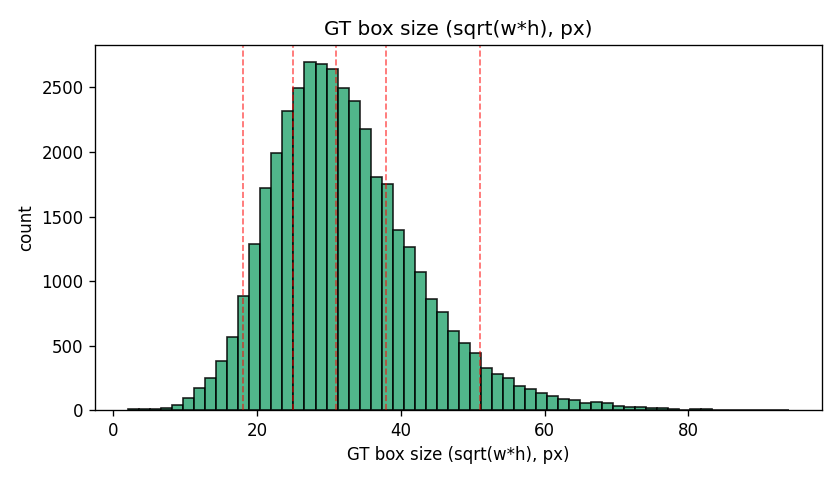

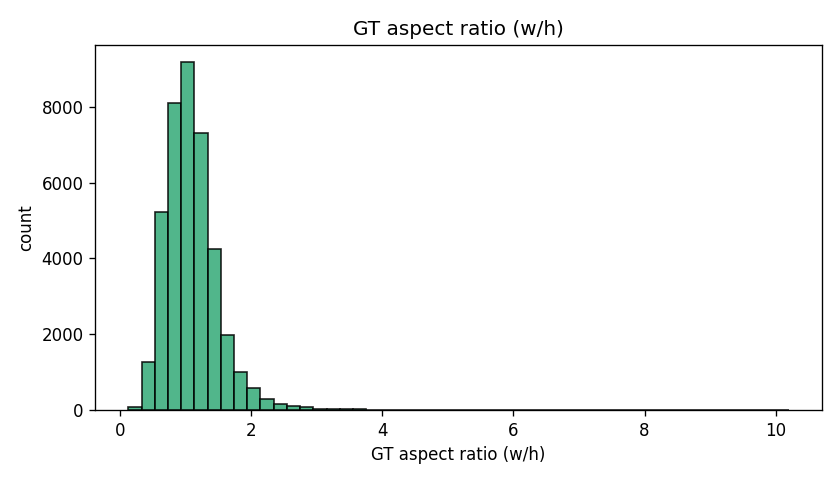

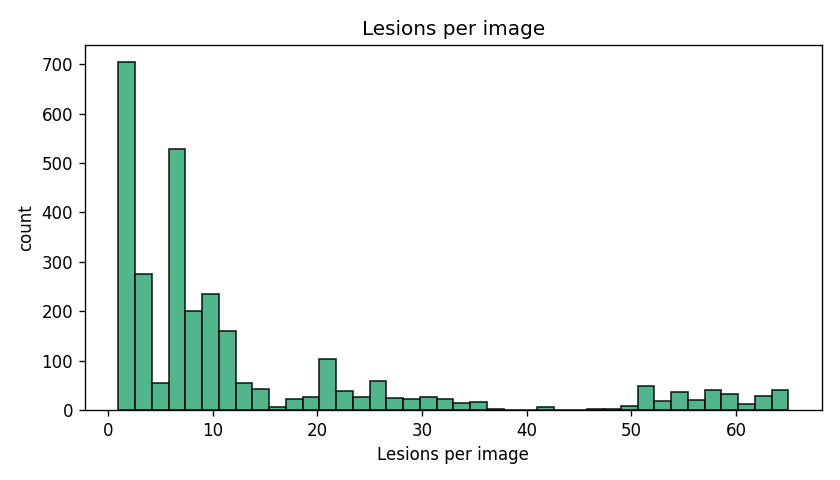

In [5]:
from part1_detection.analyze_gt import analyze
from IPython.display import Image as IPyImage, display

gt_stats = analyze(
    coco_path=f'{coco_root}/train/_annotations.coco.json',
    out_dir='outputs/eda',
)

for fn in ('gt_size_distribution.png',
           'gt_aspect_distribution.png',
           'gt_per_image.png'):
    display(IPyImage(filename=f'outputs/eda/{fn}'))


### Apply data-driven settings to the detectors

The cell below reads `gt_stats` and:

* Builds `REC_ANCHOR_SIZES` / `REC_ASPECT_RATIOS` for Faster R-CNN.
* Picks `IMGSZ` so the **median lesion is ~16 px after resize** (FPN P3 stride-8 -- the sweet spot for small-object recall). Rounded to a multiple of 32 and clipped to [640, 1536].
* Monkey-patches `train_faster_rcnn.build_model` so the training cell below picks up the new anchors with no code edit.

In [6]:
# Data-driven anchor sizes for Faster R-CNN ----------------------
REC_ANCHOR_SIZES  = tuple(tuple(t) for t in gt_stats['recommended_anchor_sizes'])
REC_ASPECT_RATIOS = tuple(gt_stats['recommended_aspect_ratios'])
print('anchor_sizes  :', REC_ANCHOR_SIZES)
print('aspect_ratios :', REC_ASPECT_RATIOS)

# Data-driven imgsz for YOLO / RT-DETR ---------------------------
# Target: median lesion == 16 px after resize.
med_lesion = gt_stats['box_size_px']['p50']
src_w      = gt_stats['image_size_median'][0]
raw_imgsz  = src_w * 16.0 / max(med_lesion, 1.0)
IMGSZ      = int(min(1536, max(640, round(raw_imgsz / 32) * 32)))
print(f'median lesion={med_lesion:.1f} px in {src_w:.0f}-px image '
      f'-> imgsz={IMGSZ}')

# Patch build_model() to use the new anchors --------------------
import part1_detection.train_faster_rcnn as _frcnn_mod
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead

_orig_build = _frcnn_mod.build_model

def _build_data_driven(num_classes=2, small_anchors=True):
    model = _orig_build(num_classes=num_classes, small_anchors=False)
    model.rpn.anchor_generator = AnchorGenerator(
        sizes=REC_ANCHOR_SIZES,
        aspect_ratios=(REC_ASPECT_RATIOS,) * len(REC_ANCHOR_SIZES),
    )
    in_ch  = model.backbone.out_channels
    n_anch = model.rpn.anchor_generator.num_anchors_per_location()[0]
    model.rpn.head = RPNHead(in_ch, n_anch)
    return model

_frcnn_mod.build_model = _build_data_driven
print('[patched] train_faster_rcnn.build_model -> data-driven anchors')


anchor_sizes  : ((14, 22), (20, 31), (25, 39), (30, 48), (41, 64))
aspect_ratios : (0.83, 1.05, 1.3)
median lesion=31.0 px in 640-px image -> imgsz=640
[patched] train_faster_rcnn.build_model -> data-driven anchors


## 2. Train YOLOv8

In [7]:
from part1_detection.train_ultralytics import train_yolo
# Use the data-driven imgsz so the median lesion is ~16 px to the model.
# Batch is left to the per-model default (8 for yolov8m) so it fits on T4.
yolo_results = train_yolo(
    data=str(yaml_path), epochs=150, imgsz=IMGSZ,
)


Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/acne_yang_project/data/acne04.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=acne, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

## 3. Train Faster R-CNN (ResNet50-FPN)

In [8]:
from part1_detection.train_faster_rcnn import train as train_frcnn
# longer schedule + smaller LR to match the bigger min/max image size and tighter anchors
frcnn_model = train_frcnn(coco_root=str(coco_root), epochs=40, batch_size=2, lr=2e-3)

train images: 2973  |  val images: 283
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 203MB/s]


  epoch 1 step 0/1487 loss 2.0851 (2.0851 avg)
  epoch 1 step 20/1487 loss 1.1053 (0.9142 avg)
  epoch 1 step 40/1487 loss 0.2252 (0.8044 avg)
  epoch 1 step 60/1487 loss 1.1603 (0.7358 avg)
  epoch 1 step 80/1487 loss 0.3927 (0.6974 avg)
  epoch 1 step 100/1487 loss 0.1529 (0.6816 avg)
  epoch 1 step 120/1487 loss 0.9687 (0.6823 avg)
  epoch 1 step 140/1487 loss 0.9898 (0.6623 avg)
  epoch 1 step 160/1487 loss 0.8465 (0.6735 avg)
  epoch 1 step 180/1487 loss 0.6159 (0.6629 avg)
  epoch 1 step 200/1487 loss 0.2450 (0.6556 avg)
  epoch 1 step 220/1487 loss 0.8354 (0.6497 avg)
  epoch 1 step 240/1487 loss 1.5180 (0.6619 avg)
  epoch 1 step 260/1487 loss 0.3358 (0.6673 avg)
  epoch 1 step 280/1487 loss 0.6135 (0.6739 avg)
  epoch 1 step 300/1487 loss 0.1075 (0.6681 avg)
  epoch 1 step 320/1487 loss 1.2521 (0.6697 avg)
  epoch 1 step 340/1487 loss 0.4846 (0.6659 avg)
  epoch 1 step 360/1487 loss 0.3760 (0.6654 avg)
  epoch 1 step 380/1487 loss 0.7912 (0.6606 avg)
  epoch 1 step 400/1487 lo

## 4. Train RT-DETR (DINO family)

In [9]:
from part1_detection.train_ultralytics import train_rtdetr
# RT-DETR benefits equally from the larger, data-driven input.
rtdetr_results = train_rtdetr(
    data=str(yaml_path), epochs=120, imgsz=IMGSZ, batch=6,
)


Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/acne_yang_project/data/acne04.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=acne, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      1/120      5.32G      1.123     0.5801     0.2434          7        640: 100% ━━━━━━━━━━━━ 496/496 2.9it/s 2:50
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.0it/s 6.1s
                   all        283       3425      0.382      0.382      0.279     0.0606

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/120      5.61G      0.984     0.5152     0.1416         34        640: 0% ──────────── 0/496  0.3s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      2/120      5.61G     0.9812     0.4975     0.1794         51        640: 100% ━━━━━━━━━━━━ 496/496 3.2it/s 2:34
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 10.6it/s 2.3s
                   all        283       3425      0.354      0.356      0.242     0.0507

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/120      5.61G      1.119      0.444     0.2733        100        640: 0% ──────────── 0/496  0.3s

...

     37/120      5.62G     0.8759     0.4821     0.1508         74        640: 100% ━━━━━━━━━━━━ 496/496 3.4it/s 2:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 12.4it/s 1.9s
                   all        283       3425          0          0          0          0
WARNING ⚠️ Skipping checkpoint save at epoch 36: EMA contains NaN/Inf

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     38/120      5.62G     0.7466     0.5343     0.1147         18        640: 0% ──────────── 0/496  0.3s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


     38/120      5.62G     0.8775     0.4796     0.1499        113        640: 100% ━━━━━━━━━━━━ 496/496 3.4it/s 2:26
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 11.9it/s 2.0s
                   all        283       3425          0          0          0          0
WARNING ⚠️ Skipping checkpoint save at epoch 37: EMA contains NaN/Inf

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     39/120      5.62G     0.7003     0.5205     0.1257         38        640: 0% ──────────── 0/496  0.3s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


     39/120      5.62G        nan        nan        nan         32        640: 100% ━━━━━━━━━━━━ 496/496 3.4it/s 2:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 12.2it/s 2.0s
                   all        283       3425          0          0          0          0
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 9, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.
WARNING ⚠️ Skipping checkpoint save at epoch 38: EMA contains NaN/Inf

39 epochs completed in 1.641 hours.
Optimizer stripped from /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/last.pt, 66.2MB
Optimizer stripped from /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt, 66.2MB

Validating /content/acne_yang_project/runs/detect/outputs/rtdetr/a

## 5. Unified Evaluation (mAP / P / R / IoU)

All three models scored with the **same pycocotools COCOeval** for an apples-to-apples comparison.

In [10]:
# Auto-discover weight files (handles both fresh-train and resume-from-Drive layouts).
import glob

def _find_best(globs):
    for g in globs:
        hits = sorted(glob.glob(g), key=lambda p: -__import__('os').path.getmtime(p))
        if hits:
            return hits[0]
    raise FileNotFoundError(f'no best.pt found in any of: {globs}')

YOLO_WEIGHTS  = _find_best([
    'runs/detect/outputs/yolov8/**/weights/best.pt',
    'outputs/yolov8/**/weights/best.pt',
    '/content/**/yolov8/**/weights/best.pt',
])
RTDETR_WEIGHTS = _find_best([
    'runs/detect/outputs/rtdetr/**/weights/best.pt',
    'outputs/rtdetr/**/weights/best.pt',
    '/content/**/rtdetr/**/weights/best.pt',
])
FRCNN_WEIGHTS  = _find_best([
    'outputs/faster_rcnn/best.pth',
    'outputs/faster_rcnn/**/best.pth',
])
print('YOLO  :', YOLO_WEIGHTS)
print('FRCNN :', FRCNN_WEIGHTS)
print('RTDETR:', RTDETR_WEIGHTS)

from part1_detection.evaluate import evaluate_model
import pandas as pd

metrics = {}
metrics['YOLOv8']       = evaluate_model('yolo',   YOLO_WEIGHTS,   str(coco_root))
metrics['Faster R-CNN'] = evaluate_model('frcnn',  FRCNN_WEIGHTS,  str(coco_root))
metrics['RT-DETR']      = evaluate_model('rtdetr', RTDETR_WEIGHTS, str(coco_root))

df = pd.DataFrame(metrics).T[
    ['mAP@0.5', 'mAP@0.5:0.95', 'precision@0.5', 'recall@0.5', 'mean_iou', 'score_thr', 'f1']
]
df


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.65s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.82s).
Accumulating evaluation results...
DONE (t=0.08s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.071
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.274
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.016
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.069
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.073
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.018
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | max

,mAP@0.5,mAP@0.5:0.95,precision@0.5,recall@0.5,mean_iou
YOLOv8,0.273718,0.070502,0.586207,0.156592,0.636457
Faster R-CNN,0.176825,0.040569,0.327438,0.351756,0.617148
RT-DETR,0.285748,0.065291,0.298497,0.503166,0.628199


## 6. Side-by-side bbox visualizations

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
saved outputs/viz/predictions_test.png


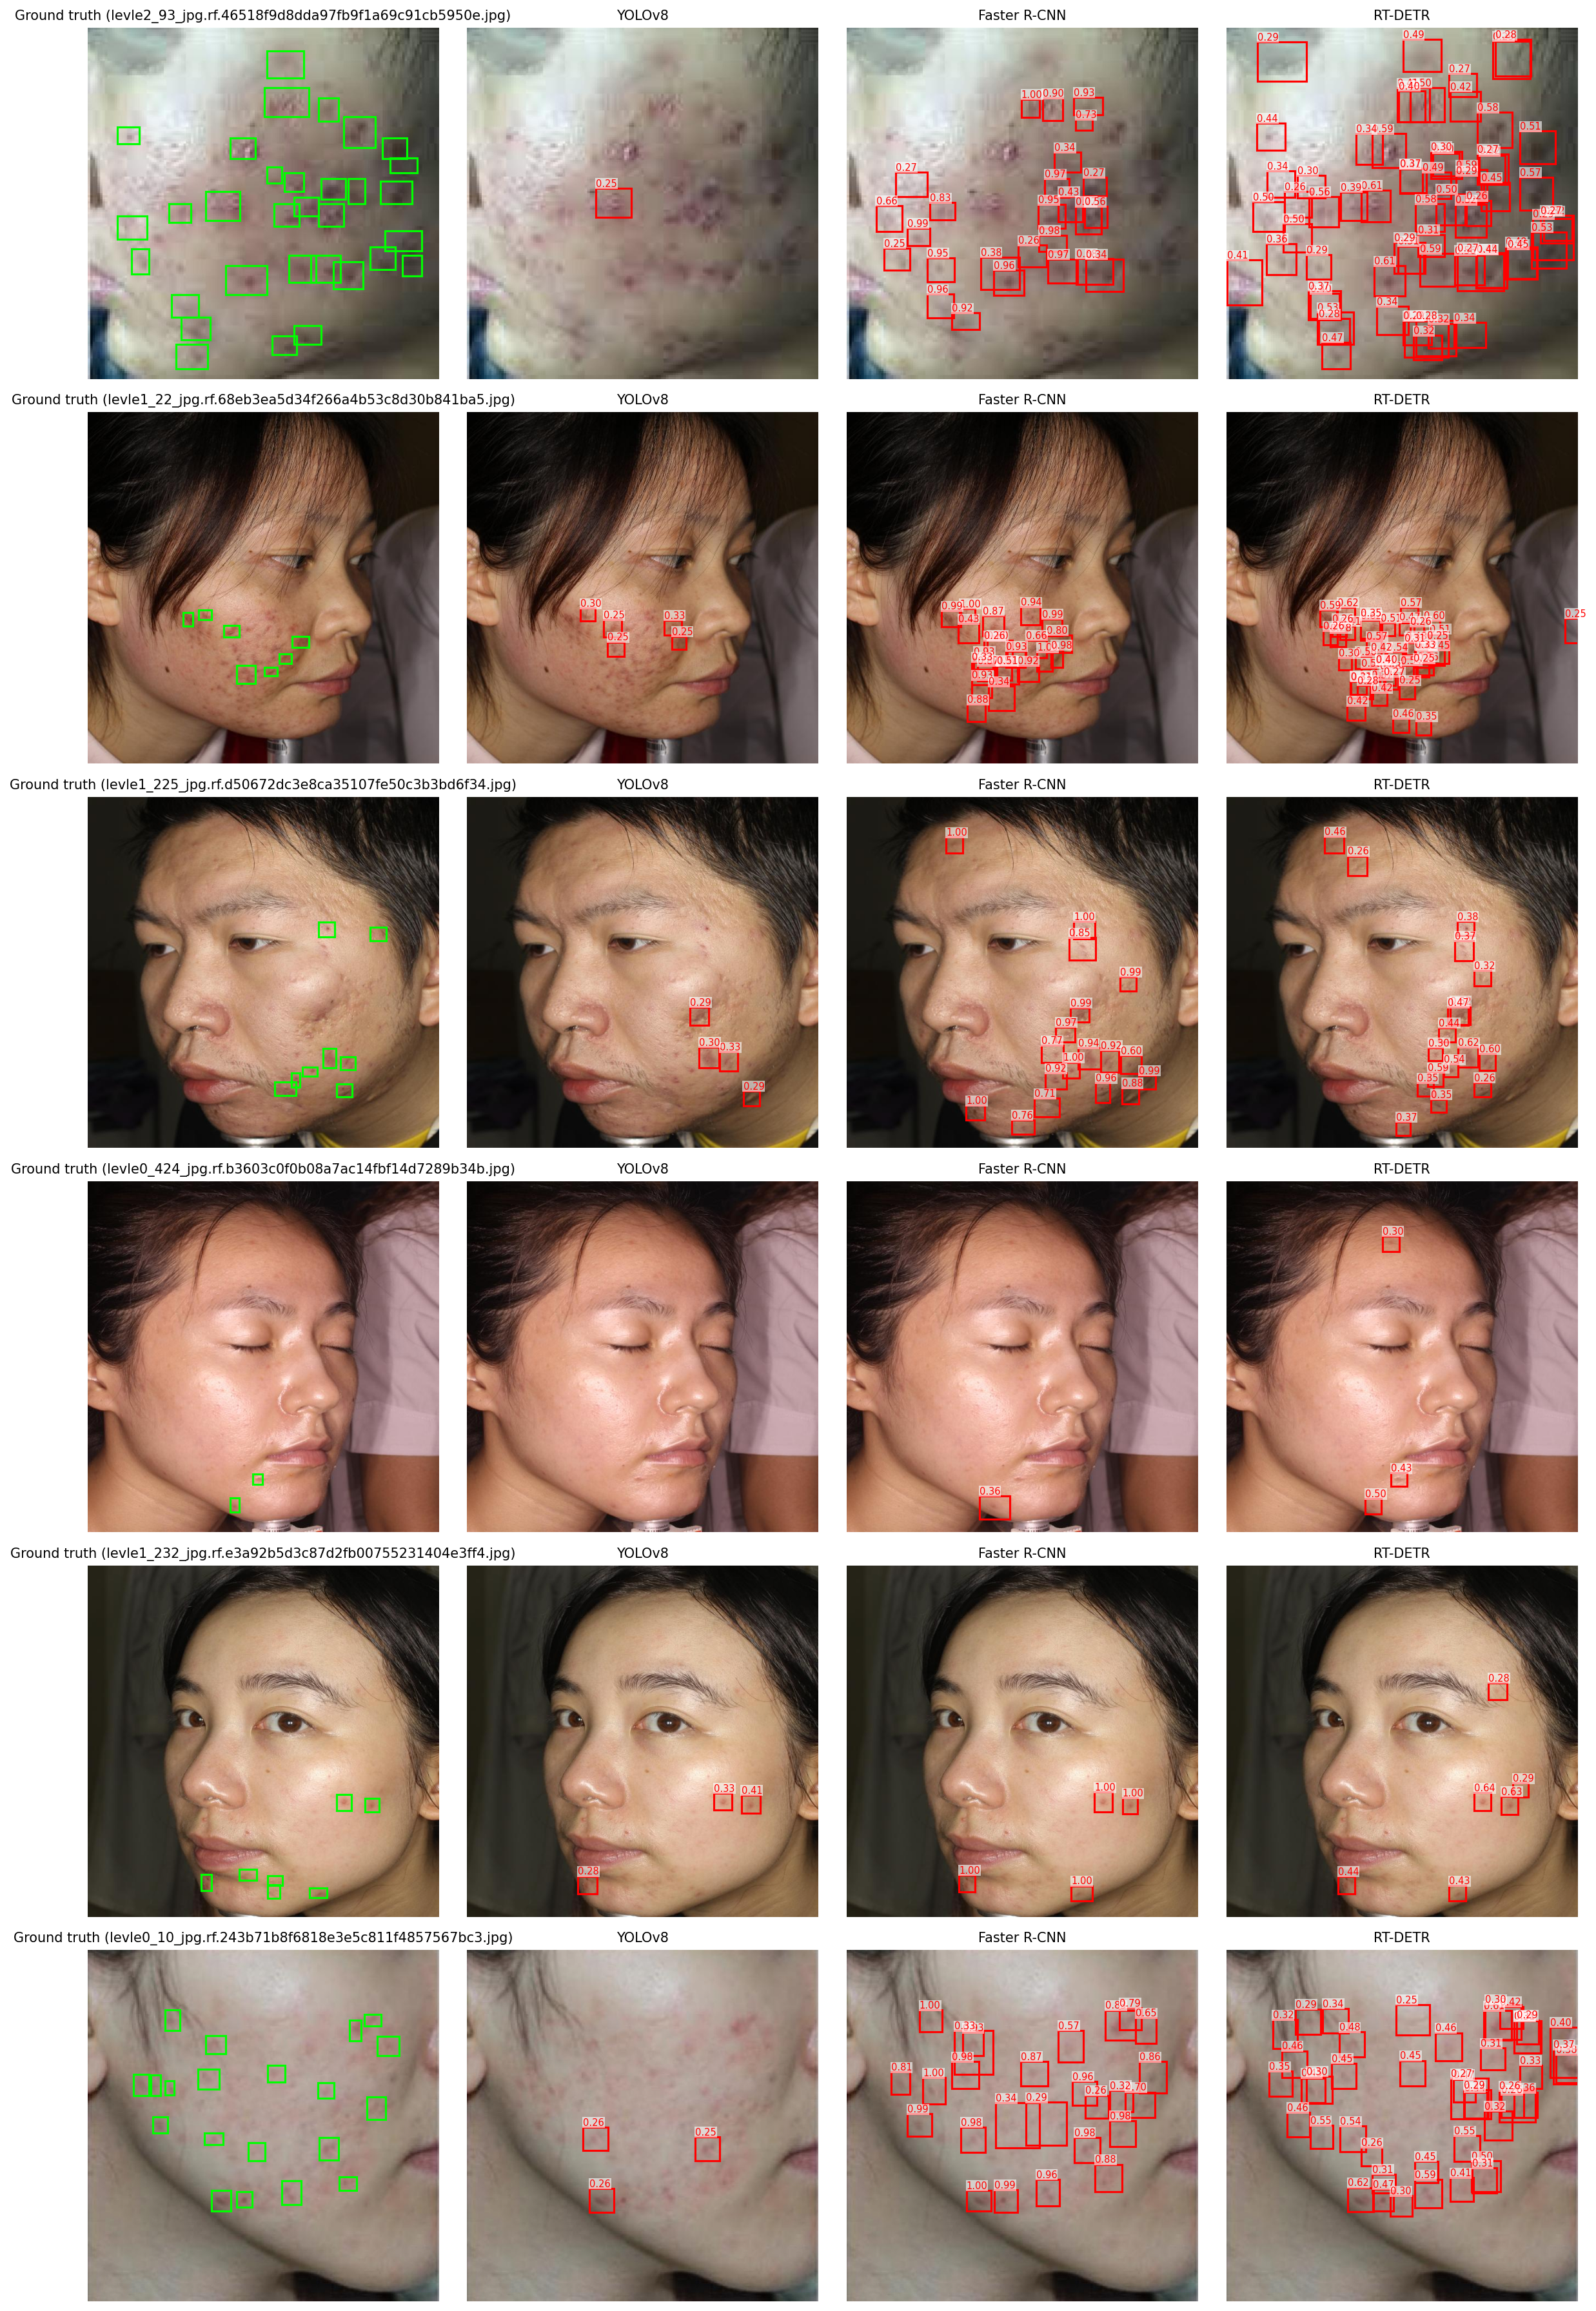

In [11]:
from part1_detection.visualize import visualize_predictions
from IPython.display import Image as IPyImage

out = visualize_predictions(
    models={
        'YOLOv8':       {'kind': 'yolo',   'weights': YOLO_WEIGHTS},
        'Faster R-CNN': {'kind': 'frcnn',  'weights': FRCNN_WEIGHTS},
        'RT-DETR':      {'kind': 'rtdetr', 'weights': RTDETR_WEIGHTS},
    },
    coco_root=str(coco_root),
    n_images=6,
)
IPyImage(filename=str(out))


In [12]:
# === Save all training artifacts to Google Drive ===
import os, shutil, datetime
DRIVE_ROOT = '/content/drive/MyDrive/acne_yang_project_runs'

# (optional) keep a timestamped snapshot so you don't overwrite earlier runs
SNAPSHOT = os.path.join(DRIVE_ROOT, datetime.datetime.now().strftime('snap_%Y%m%d_%H%M'))
os.makedirs(SNAPSHOT, exist_ok=True)

for src in ['outputs', 'runs']:
    if os.path.isdir(src):
        dst_latest   = os.path.join(DRIVE_ROOT, src)          # always-current copy
        dst_snapshot = os.path.join(SNAPSHOT,   src)          # frozen copy
        print(f'[save] {src}/ -> {dst_latest}/ (+ snapshot)')
        shutil.copytree(src, dst_latest,   dirs_exist_ok=True)
        shutil.copytree(src, dst_snapshot, dirs_exist_ok=True)
    else:
        print(f'[skip] {src}/ does not exist')

print('\n[save] done. Drive contents:')
!ls -lh "$DRIVE_ROOT"
print('\n[save] snapshot saved at:', SNAPSHOT)


[save] outputs/ -> /content/drive/MyDrive/acne_yang_project_runs/outputs/ (+ snapshot)
[save] runs/ -> /content/drive/MyDrive/acne_yang_project_runs/runs/ (+ snapshot)

[save] done. Drive contents:
total 24K
drwx------ 6 root root 4.0K May 14 02:20 outputs
drwx------ 3 root root 4.0K May 13 22:12 runs
drwx------ 2 root root 4.0K May 12 01:04 snap_20260512_0104
drwx------ 2 root root 4.0K May 12 09:28 snap_20260512_0928
drwx------ 2 root root 4.0K May 13 03:06 snap_20260513_0306
drwx------ 4 root root 4.0K May 14 02:21 snap_20260514_0220

[save] snapshot saved at: /content/drive/MyDrive/acne_yang_project_runs/snap_20260514_0220
